In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold, train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance 
from sklearn.feature_selection import RFE, SelectFromModel
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score


from matplotlib.ticker import AutoMinorLocator


import time

In [ ]:

# Alternatively, customize matplotlib rcParams
plt.rcParams.update({
    "figure.figsize": (10, 6), 
    "axes.titlesize": 18,     
    "axes.labelsize": 18,     
    "xtick.labelsize": 18,     
    "ytick.labelsize": 18,     
    "legend.fontsize": 16,    
})

In [3]:
df = pd.read_csv(r'C:\Users\magic\OneDrive\Desktop\Programas\Python_programs\data_analysis_2\classic_machine_learning\df_extra_dataset.csv')
df

,patient_nbr,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_4,...,citoglipton_Steady,glyburide_No,glyburide_Steady,glyburide_Up,insulin_No,insulin_Steady,insulin_Up,change_No,diabetesMed_Yes,readmitted_YES
0,41186889,0.8,13,69,4,38,0,0,1,764.938726,...,True,True,False,False,False,True,False,True,True,False
1,83591073,0.8,5,34,0,4,0,0,0,289.692993,...,True,True,False,False,True,False,False,True,False,False
2,68337009,0.6,1,37,1,13,3,0,0,261.207404,...,True,True,False,False,False,True,False,True,True,False
3,73175076,0.4,4,56,2,22,0,0,0,239.239855,...,True,True,False,False,False,False,True,False,True,True
4,31718349,0.7,1,38,2,1,0,1,2,447.777469,...,True,True,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,6316443,0.8,3,47,3,8,0,0,0,436.278826,...,True,False,False,False,True,False,False,False,True,True
4996,96364728,0.7,8,52,0,17,2,0,0,100.470643,...,True,False,False,True,True,False,False,False,True,True
4997,101621745,0.5,1,17,0,11,0,0,0,252.534331,...,True,False,True,False,False,True,False,False,True,False
4998,21969333,0.7,2,42,6,12,0,0,0,490.513630,...,False,True,False,False,True,False,False,True,True,True


Scaling all the features

In [4]:


scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
df_scaled

,patient_nbr,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_4,...,citoglipton_Steady,glyburide_No,glyburide_Steady,glyburide_Up,insulin_No,insulin_Steady,insulin_Up,change_No,diabetesMed_Yes,readmitted_YES
0,0.217554,0.888889,0.923077,0.635514,0.666667,0.578125,0.000000,0.000000,0.066667,0.505132,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
1,0.441567,0.888889,0.307692,0.308411,0.000000,0.046875,0.000000,0.000000,0.000000,0.189173,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,0.360983,0.666667,0.000000,0.336449,0.166667,0.187500,0.076923,0.000000,0.000000,0.170235,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
3,0.386542,0.444444,0.230769,0.514019,0.333333,0.328125,0.000000,0.000000,0.000000,0.155630,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
4,0.167534,0.777778,0.000000,0.345794,0.333333,0.000000,0.000000,0.045455,0.133333,0.294273,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,0.033341,0.888889,0.153846,0.429907,0.500000,0.109375,0.000000,0.000000,0.000000,0.286628,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
4996,0.509048,0.777778,0.538462,0.476636,0.000000,0.250000,0.051282,0.000000,0.000000,0.063371,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0
4997,0.536819,0.555556,0.000000,0.149533,0.000000,0.156250,0.000000,0.000000,0.000000,0.164468,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4998,0.116032,0.777778,0.076923,0.383178,1.000000,0.171875,0.000000,0.000000,0.000000,0.322685,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0


Here I prepare a random forest to see which are the most relevant features

# Feature importance based on mean decrease in impurity (based on a forest of trees)

In [5]:
# Define random seed for reproducibility
random_seed = 2

# Split the data into features and target
X = df_scaled.drop(columns=['readmitted_YES'])
y = df_scaled['readmitted_YES']

# Split into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_seed, stratify=y)

feature_names = X.columns.tolist()
forest = RandomForestClassifier(random_state= random_seed)
forest.fit(X_train, y_train)


RandomForestClassifier(random_state=2)

# Feature importance based on feature permutation (based on a forest of trees)

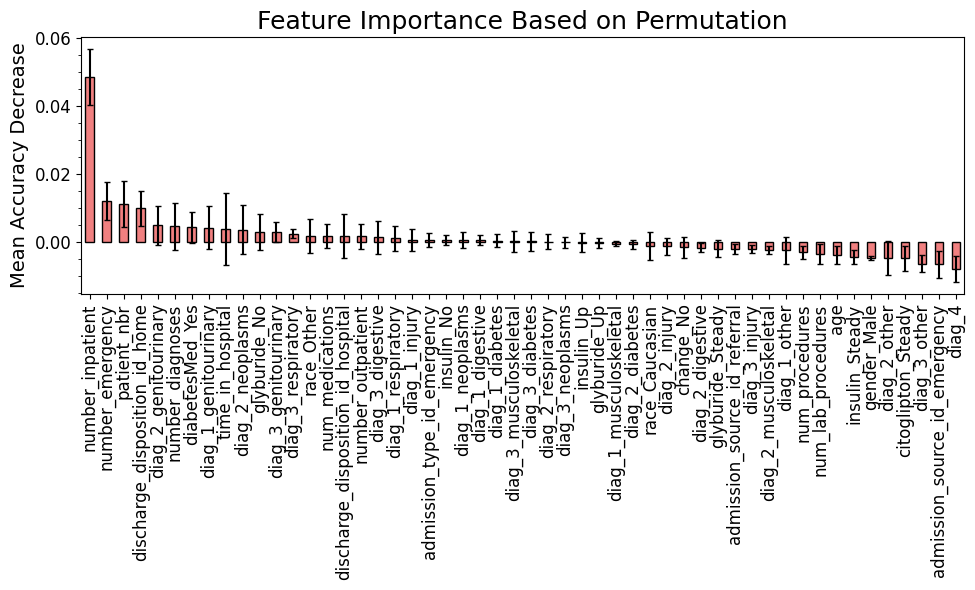

In [ ]:
result = permutation_importance(
    forest, X_test, y_test, n_repeats=50, n_jobs=5
)

perm_importances = pd.Series(result.importances_mean, index=feature_names)

perm_importances = perm_importances.sort_values(ascending=False)


fig, ax = plt.subplots(figsize=(10, 6))

perm_importances.plot.bar(
    yerr=result.importances_std,
    ax=ax,
    capsize=2,
    color='lightcoral',
    edgecolor='black'
)

ax.set_ylabel("Mean Accuracy Decrease", fontsize=14)
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_title("Feature Importance Based on Permutation", fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=12)  
fig.tight_layout()

plt.show()


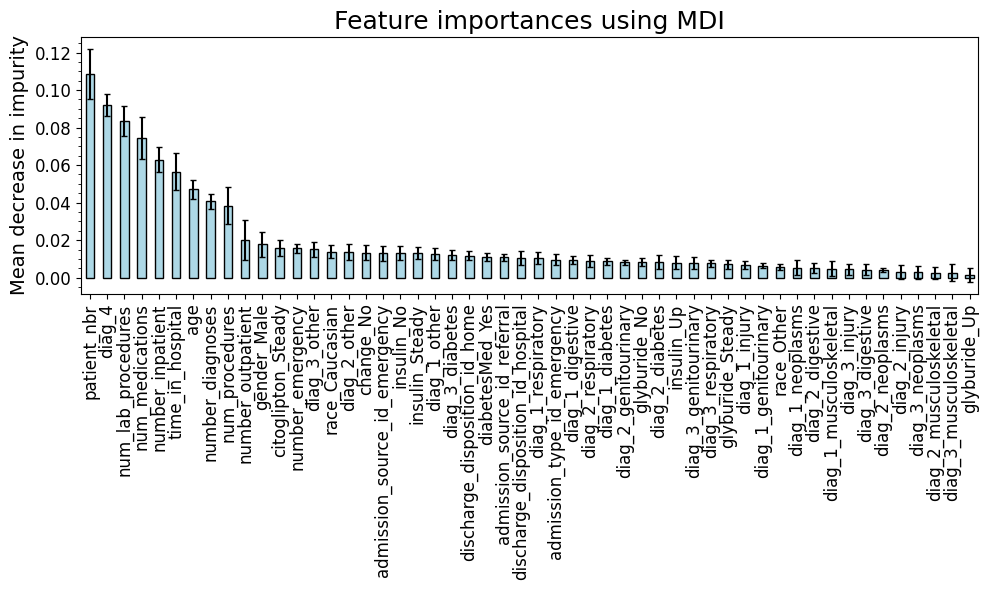

In [ ]:

importances = forest.feature_importances_
std = np.std([tree.feature_importances_ for tree in forest.estimators_], axis=0)

mdi_importances = pd.Series(importances, index=feature_names)

mdi_importances = mdi_importances.sort_values(ascending=False)


fig, ax = plt.subplots(figsize=(10, 6))

mdi_importances.plot.bar(
    yerr=std,
    ax=ax,
    capsize=2,
    color='lightblue',
    edgecolor='black'
)
ax.set_title("Feature importances using MDI", fontsize=18)
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_ylabel("Mean decrease in impurity", fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=12)
fig.tight_layout()


Here I created a ranking score for both tests. The higher your mean decrease, the higher your score. Then I compute the total score from both tests and finally I decide to have only the features with the highest score.

In [ ]:
# Rank features and assign scores
n_features = len(feature_names)

perm_ranks = perm_importances.rank(ascending=False, method="dense").astype(int)
perm_scores = n_features - perm_ranks + 1  

mdi_ranks = mdi_importances.rank(ascending=False, method="dense").astype(int)
mdi_scores = n_features - mdi_ranks + 1 

# Combine into a DataFrame
importance_scores = pd.DataFrame({
    "Permutation Importance": perm_importances,
    "Permutation Score": perm_scores,
    "MDI Importance": mdi_importances,
    "MDI Score": mdi_scores,
    "Total Score": perm_scores + mdi_scores  
})

importance_scores = importance_scores.sort_values(by="Total Score", ascending=False)

importance_scores

,Permutation Importance,Permutation Score,MDI Importance,MDI Score,Total Score
patient_nbr,0.01122,50,0.108575,52,102
number_inpatient,0.04854,52,0.062936,48,100
number_diagnoses,0.00468,47,0.040722,45,92
number_emergency,0.01204,51,0.015595,40,91
time_in_hospital,0.00390,44,0.056486,47,91
num_medications,0.00178,38,0.074552,49,87
number_outpatient,0.00170,36,0.020129,43,79
discharge_disposition_id_home,0.01000,49,0.011680,30,79
diabetesMed_Yes,0.00444,46,0.011103,29,75
diag_2_genitourinary,0.00492,48,0.008205,21,69


Now I have a list from the most relevant features to the lowest relevant features I would like to test the accuracy of the forest as I features. I would start from the most important feature and I would continue adding until the last one. Then I will like to plot those results with error bars.

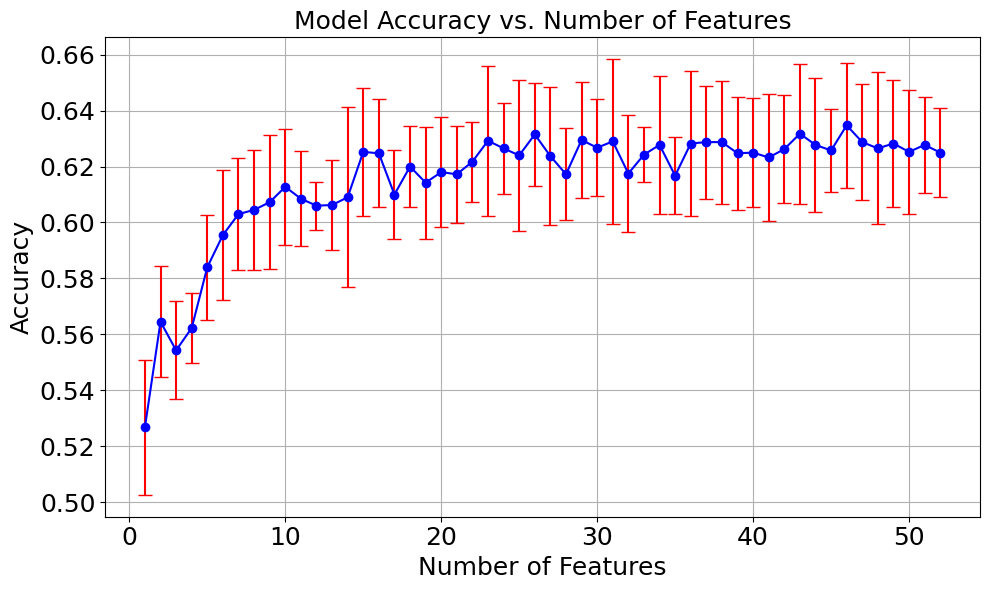

In [ ]:

# Sort features by importance (descending order)
sorted_features = importance_scores.index.tolist()

mean_accuracies = []
std_accuracies = []

# Incrementally add features and evaluate accuracy
for i in range(1, len(sorted_features) + 1):
    selected_features = sorted_features[:i]
    X_subset = X_train[selected_features]
    
    # Perform 10-fold cross-validation
    scores = cross_val_score(forest, X_subset, y_train, cv=10, scoring='accuracy', n_jobs=6)
    
    # Store mean and standard deviation of accuracy
    mean_accuracies.append(scores.mean())
    std_accuracies.append(scores.std())

fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(range(1, len(sorted_features) + 1), mean_accuracies, yerr=std_accuracies, fmt='-o', capsize=5, color='blue', ecolor='red')
ax.set_xlabel("Number of Features")
ax.set_ylabel("Accuracy")
ax.set_title("Model Accuracy vs. Number of Features")
ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
#Select the top features based on the total score
top_features = importance_scores.nlargest(20, 'Total Score').index

df_scaled_cleaned = df_scaled[top_features]

In [11]:

df_scaled_cleaned = df_scaled_cleaned.copy()

df_scaled_cleaned['readmitted_YES'] = df_scaled['readmitted_YES']

In [12]:
df_scaled_cleaned

,patient_nbr,number_inpatient,number_diagnoses,number_emergency,time_in_hospital,num_medications,number_outpatient,discharge_disposition_id_home,diabetesMed_Yes,diag_2_genitourinary,...,discharge_disposition_id_hospital,glyburide_No,diag_1_respiratory,num_lab_procedures,diag_3_genitourinary,diag_1_genitourinary,admission_type_id_emergency,diag_3_diabetes,race_Caucasian,readmitted_YES
0,0.217554,0.066667,0.533333,0.000000,0.923077,0.578125,0.000000,1.0,1.0,0.0,...,0.0,1.0,0.0,0.635514,0.0,0.0,1.0,0.0,1.0,0.0
1,0.441567,0.000000,0.400000,0.000000,0.307692,0.046875,0.000000,1.0,0.0,0.0,...,0.0,1.0,0.0,0.308411,0.0,0.0,1.0,0.0,1.0,0.0
2,0.360983,0.000000,0.266667,0.000000,0.000000,0.187500,0.076923,0.0,1.0,0.0,...,1.0,1.0,0.0,0.336449,0.0,0.0,1.0,0.0,0.0,0.0
3,0.386542,0.000000,0.533333,0.000000,0.230769,0.328125,0.000000,1.0,1.0,0.0,...,0.0,1.0,0.0,0.514019,1.0,0.0,1.0,0.0,1.0,1.0
4,0.167534,0.133333,0.400000,0.045455,0.000000,0.000000,0.000000,1.0,0.0,0.0,...,0.0,1.0,0.0,0.345794,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,0.033341,0.000000,0.333333,0.000000,0.153846,0.109375,0.000000,1.0,1.0,0.0,...,0.0,0.0,0.0,0.429907,1.0,0.0,1.0,0.0,1.0,1.0
4996,0.509048,0.000000,0.533333,0.000000,0.538462,0.250000,0.051282,1.0,1.0,0.0,...,0.0,0.0,0.0,0.476636,0.0,0.0,1.0,0.0,1.0,1.0
4997,0.536819,0.000000,0.533333,0.000000,0.000000,0.156250,0.000000,1.0,1.0,0.0,...,0.0,0.0,1.0,0.149533,0.0,0.0,1.0,0.0,1.0,0.0
4998,0.116032,0.000000,0.466667,0.000000,0.076923,0.171875,0.000000,1.0,1.0,0.0,...,0.0,1.0,0.0,0.383178,0.0,0.0,1.0,0.0,1.0,1.0


In [ ]:

random_seed = 2

#Split the data into features and target
X = df_scaled_cleaned.drop(columns=['readmitted_YES'])
y = df_scaled_cleaned['readmitted_YES']

#Split into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_seed, stratify=y)

feature_names = X.columns.tolist()
forest = RandomForestClassifier(random_state= random_seed)
forest.fit(X_train, y_train)

RandomForestClassifier(random_state=2)

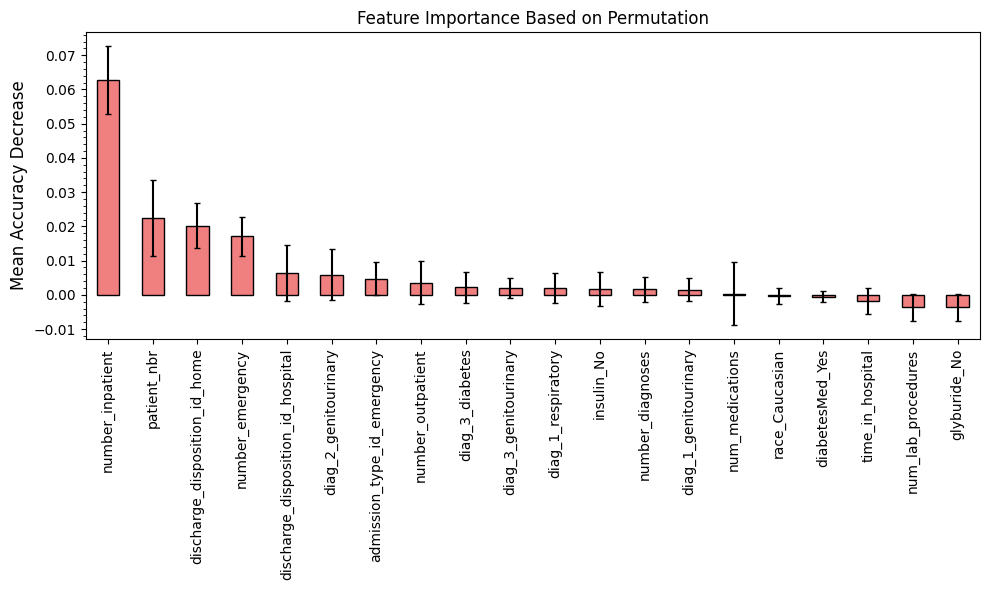

In [ ]:
result = permutation_importance(
    forest, X_test, y_test, n_repeats=50, random_state=random_seed, n_jobs=5
)

perm_importances = pd.Series(result.importances_mean, index=feature_names)

perm_importances = perm_importances.sort_values(ascending=False)


fig, ax = plt.subplots(figsize=(10, 6))

perm_importances.plot.bar(
    yerr=result.importances_std,
    ax=ax,
    capsize=2,
    color='lightcoral',
    edgecolor='black'
)

ax.set_ylabel("Mean Accuracy Decrease", fontsize=12)
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_title("Feature Importance Based on Permutation", fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=10)
fig.tight_layout()

plt.show()


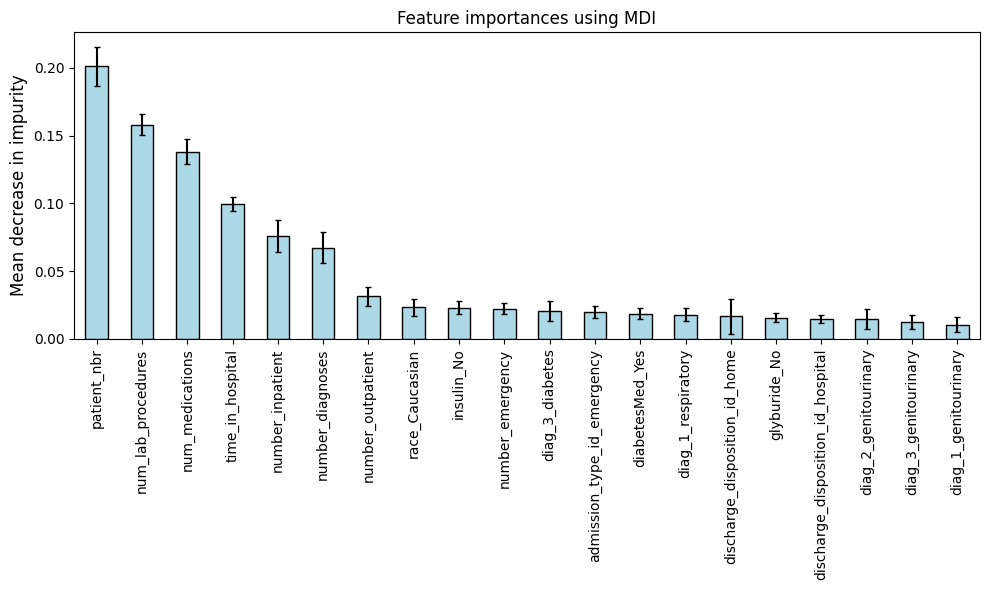

In [ ]:

importances = forest.feature_importances_
std = np.std([tree.feature_importances_ for tree in forest.estimators_], axis=0)

mdi_importances = pd.Series(importances, index=feature_names)

mdi_importances = mdi_importances.sort_values(ascending=False)
n
fig, ax = plt.subplots(figsize=(10, 6))

mdi_importances.plot.bar(
    yerr=std,
    ax=ax,
    capsize=2,
    color='lightblue',
    edgecolor='black'
)
ax.set_title("Feature importances using MDI", fontsize=12)
ax.set_ylabel("Mean decrease in impurity", fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=10)
fig.tight_layout()


Once we have selected the most important features, we want to apply multiple Machine Learning algorithms in order to see its preformance classifying and how long does it take to each one.

I want to apply KNN to df_scaled_cleaned using different number of neighbors. For each case I want to do a 10-fold cross validation. Also, in each case, I want to know the classification score and the time it lasted to do the classificaiton and compute the average and the std and do both plots depending on the number of neighbors

In [16]:
# Features and target
X = df_scaled_cleaned.drop(columns=['readmitted_YES'])
y = df_scaled_cleaned['readmitted_YES']

# KNN

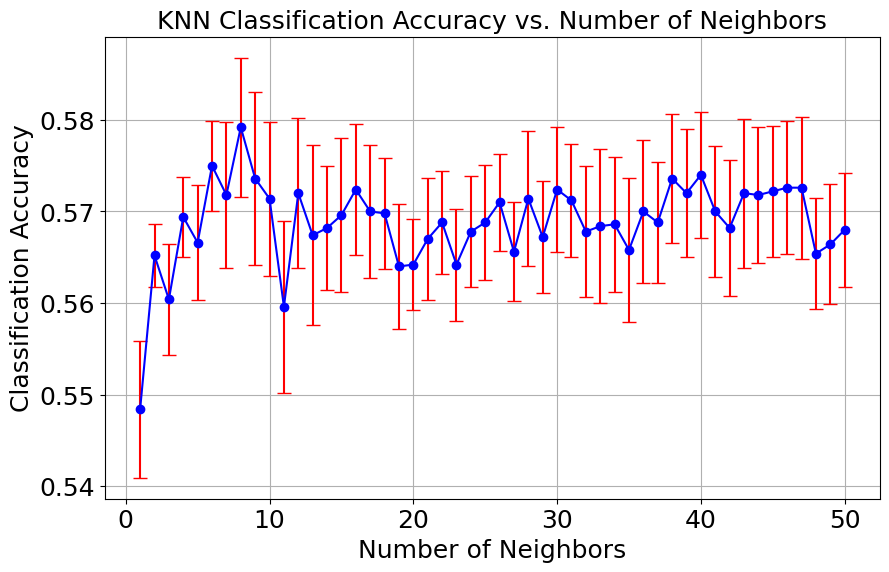

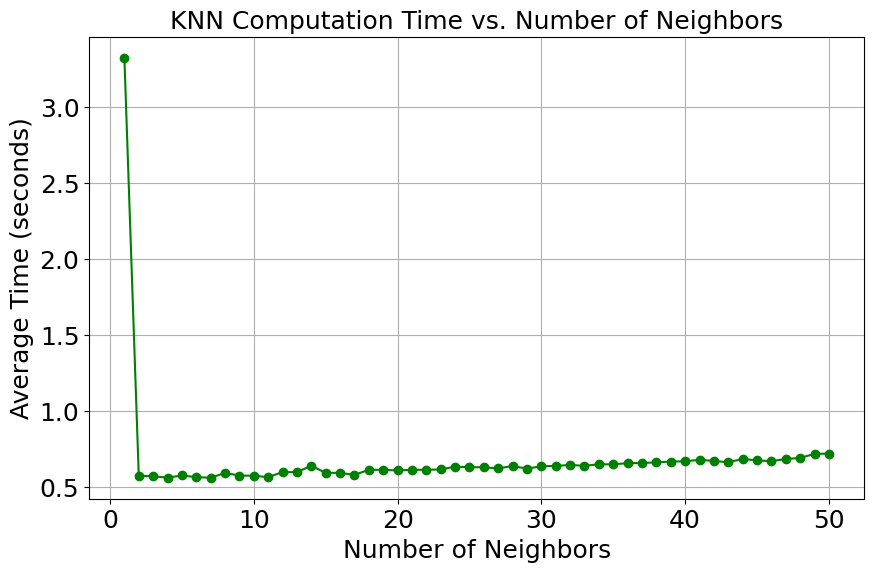

The best number of neighbors is: 8


In [ ]:
from sklearn.neighbors import KNeighborsClassifier


# Define the range of neighbors to test
neighbors_range = range(1, 51)

mean_scores = []
std_scores = []
mean_times = []



#Loop through each number of neighbors
for n_neighbors in neighbors_range:
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    
    #Measure time for cross-validation
    start_time = time.time()
    for _ in range(1,101):
        scores = cross_val_score(knn, X, y, cv=10, scoring='accuracy', n_jobs=-1)
    elapsed_time = time.time() - start_time
    
    #Store results
    mean_scores.append(scores.mean())
    std_scores.append(scores.std()/np.sqrt(10))
    mean_times.append(elapsed_time / 10)  # Average time per fold

#Plot
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.errorbar(neighbors_range, mean_scores, yerr=std_scores, fmt='-o', capsize=5, color='blue', ecolor='red')
ax1.set_xlabel("Number of Neighbors")
ax1.set_ylabel("Classification Accuracy")
ax1.set_title("KNN Classification Accuracy vs. Number of Neighbors")
ax1.grid(True)


fig, ax2 = plt.subplots(figsize=(10, 6))
ax2.plot(neighbors_range, mean_times, '-o', color='green')
ax2.set_xlabel("Number of Neighbors")
ax2.set_ylabel("Average Time (seconds)")
ax2.set_title("KNN Computation Time vs. Number of Neighbors")
ax2.grid(True)

plt.show()

best_n_neighbors = neighbors_range[np.argmax(mean_scores)]
print(f"The best number of neighbors is: {best_n_neighbors}")

Seems to be that the one which gives the best results is with 8 neighbors

# Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

#Initialize the Decision Tree Classifier
decision_tree = DecisionTreeClassifier(random_state=random_seed)

#Define the range of maximum depths to test
max_depth_range = range(1, 51)


mean_scores_dt = []
std_scores_dt = []
mean_times_dt = []


#Loop through each maximum depth
for max_depth in max_depth_range:
    decision_tree.set_params(max_depth=max_depth)
    
    #Measure time for cross-validation
    start_time = time.time()
    for _ in range(1,101):
        scores = cross_val_score(decision_tree, X, y, cv=10, scoring='accuracy', n_jobs=-1)
    elapsed_time = time.time() - start_time
    
    #Store results
    mean_scores_dt.append(scores.mean())
    std_scores_dt.append(scores.std()/np.sqrt(10))
    mean_times_dt.append(elapsed_time / 10)  #Average time per fold

#Plot
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.errorbar(max_depth_range, mean_scores_dt, yerr=std_scores_dt, fmt='-o', capsize=5, color='blue', ecolor='red')
ax1.set_xlabel("Maximum Depth")
ax1.set_ylabel("Classification Accuracy")
ax1.set_title("Decision Tree Classification Accuracy vs. Maximum Depth")
ax1.grid(True)

fig, ax2 = plt.subplots(figsize=(10, 6))
ax2.plot(max_depth_range, mean_times_dt, '-o', color='green')
ax2.set_xlabel("Maximum Depth")
ax2.set_ylabel("Average Time (seconds)")
ax2.set_title("Decision Tree Computation Time vs. Maximum Depth")
ax2.grid(True)

plt.show()
best_max_depth = max_depth_range[np.argmax(mean_scores_dt)]
print(f"The best maximum depth is: {best_max_depth}")


Seems that the best depth for the decision tree is 4

# Random Forest

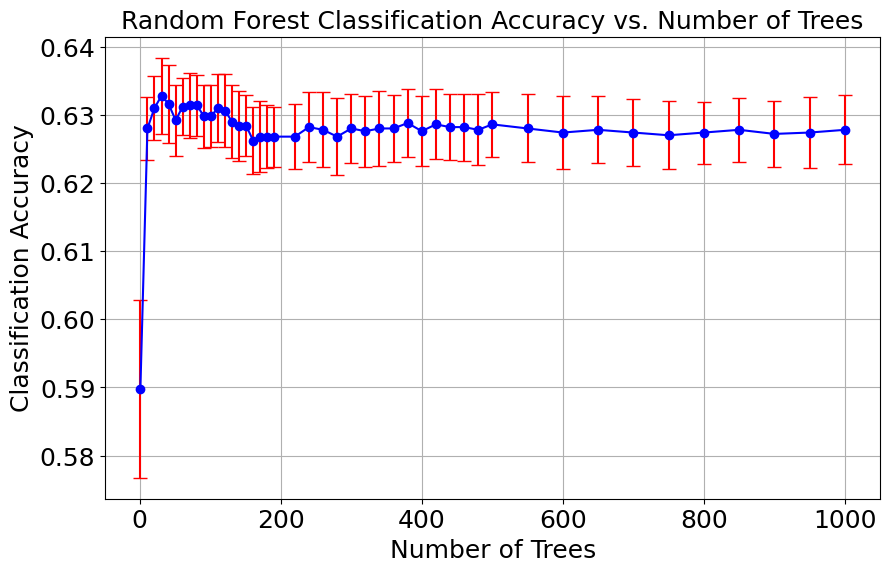

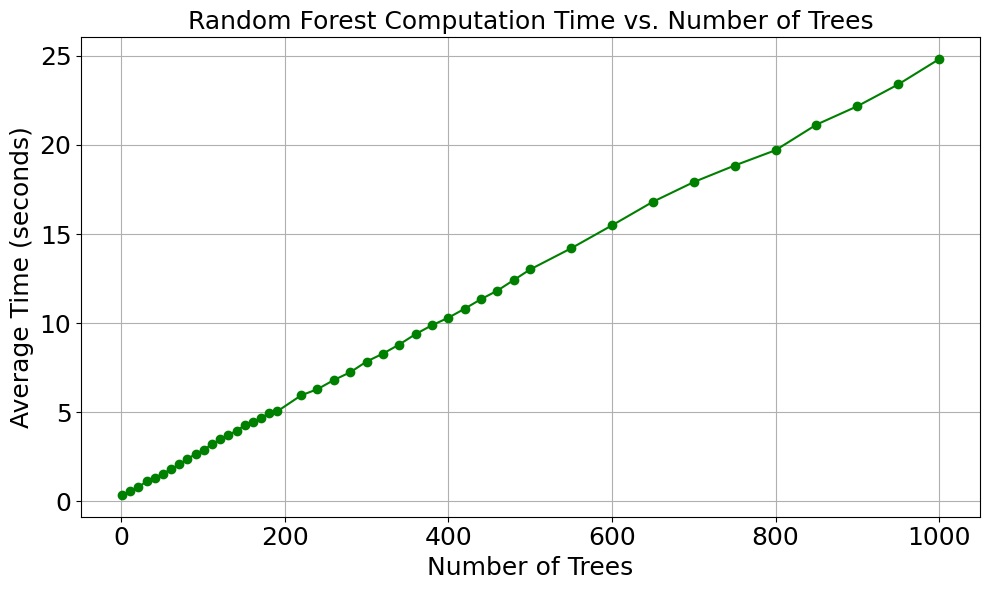

The best number of trees is: 31


In [ ]:
# Initialize the Random Forest Classifier with a fixed depth of 4
random_forest = RandomForestClassifier(max_depth=4, random_state=random_seed)

# Define the range of the number of trees to test
n_estimators_range =   list(range(1, 201, 10)) + list(range(220, 501, 20)) + list(range(550, 1001, 50))

# Initialize lists to store results
mean_scores_rf = []
std_scores_rf = []
mean_times_dt = []

# Loop through each number of trees
for n_estimators in n_estimators_range:
    random_forest.set_params(n_estimators=n_estimators)
    
    # Perform 10-fold cross-validation
    start_time = time.time()
    for _ in range(1,101):
        scores = cross_val_score(random_forest, X, y, cv=10, scoring='accuracy', n_jobs=-1)
    elapsed_time = time.time() - start_time
    
    # Store results
    mean_scores_rf.append(scores.mean())
    std_scores_rf.append(scores.std()/np.sqrt(10))
    mean_times_dt.append(elapsed_time / 10)  #Average time per fold


#Plot classification scores
fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(n_estimators_range, mean_scores_rf, yerr=std_scores_rf, fmt='-o', capsize=5, color='blue', ecolor='red')
ax.set_xlabel("Number of Trees")
ax.set_ylabel("Classification Accuracy")
ax.set_title("Random Forest Classification Accuracy vs. Number of Trees")
ax.grid(True)

fig, ax2 = plt.subplots(figsize=(10, 6))
ax2.plot(n_estimators_range, mean_times_dt, '-o', color='green')
ax2.set_xlabel("Number of Trees")
ax2.set_ylabel("Average Time (seconds)")
ax2.set_title("Random Forest Computation Time vs. Number of Trees")
ax2.grid(True)

plt.tight_layout()
plt.show()

best_n_estimators = n_estimators_range[np.argmax(mean_scores_rf)]
print(f"The best number of trees is: {best_n_estimators}")


Seems to be that the optimal quantity of trees is 41

# Naive Bayes Approach

In [ ]:
from sklearn.naive_bayes import GaussianNB

# Initialize the Naive Bayes Classifier
naive_bayes = GaussianNB()

#Perform 10-fold cross-validation
start_time = time.time()
for _ in range(101):
    scores = cross_val_score(naive_bayes, X, y, cv=10, scoring='accuracy', n_jobs=-1)
elapsed_time = time.time() - start_time

#Calculate mean and standard deviation of accuracy
mean_score_nb = scores.mean()
std_score_nb = scores.std()/np.sqrt(10)

# Print results
print(f"Naive Bayes Classification Accuracy: {mean_score_nb:.4f} ± {std_score_nb:.4f}")
print(f"Elapsed Time: {elapsed_time:.4f} seconds")


Naive Bayes Classification Accuracy: 0.6080 ± 0.0047
Elapsed Time: 2.5155 seconds


# Support Vector Machines (SVM)

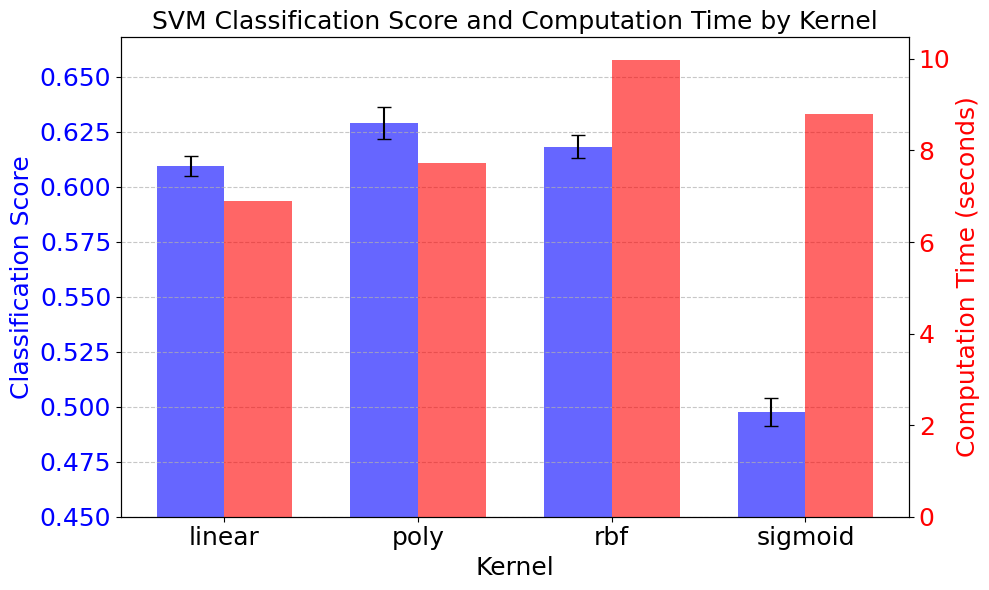

The best kernel is: poly


In [ ]:
from sklearn.svm import SVC

#Define the kernels to test
kernels = ['linear', 'poly', 'rbf', 'sigmoid']

#Initialize lists to store results
mean_scores_svm = []
std_scores_svm = []
mean_times_svm = []

#Loop through each kernel
for kernel in kernels:
    svm = SVC(kernel=kernel, random_state=random_seed)
    
    #Measure time for cross-validation
    start_time = time.time()
    for _ in range(1,101):
        scores = cross_val_score(svm, X, y, cv=10, scoring='accuracy', n_jobs=-1)
    elapsed_time = time.time() - start_time
    
    #Store results
    mean_scores_svm.append(scores.mean())
    std_scores_svm.append(scores.std()/np.sqrt(10))
    mean_times_svm.append(elapsed_time / 10)  #Average time per fold

#Plot
x = np.arange(len(kernels))  # the label locations
width = 0.35  # the width of the bars
fig, ax1 = plt.subplots(figsize=(10, 6))

bars1 = ax1.bar(x - width/2, mean_scores_svm, width, yerr=std_scores_svm, label='Classification Score', color='blue', alpha=0.6, capsize=5)
ax1.set_xlabel("Kernel")
ax1.set_ylabel("Classification Score", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_ylim(bottom=0.45)  

ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, mean_times_svm, width, label='Computation Time (seconds)', color='red', alpha=0.6, capsize=5)
ax2.set_ylabel("Computation Time (seconds)", color='red')
ax2.tick_params(axis='y', labelcolor='red')

ax1.set_title("SVM Classification Score and Computation Time by Kernel")
ax1.set_xticks(x)
ax1.set_xticklabels(kernels)

ax1.grid(axis='y', linestyle='--', alpha=0.7)

fig.tight_layout()
plt.show()

best_kernel = kernels[np.argmax(mean_scores_svm)]
print(f"The best kernel is: {best_kernel}")


# Logistic Regression Model

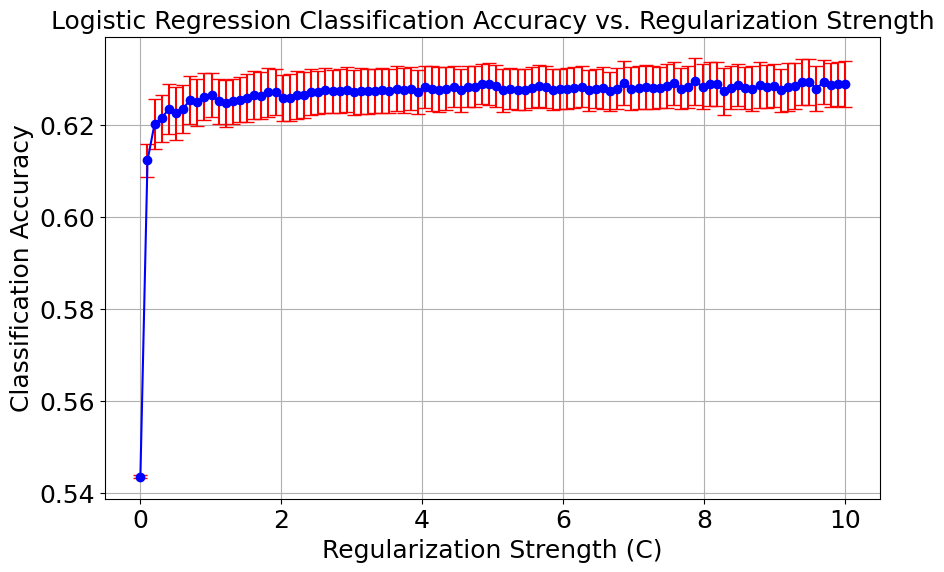

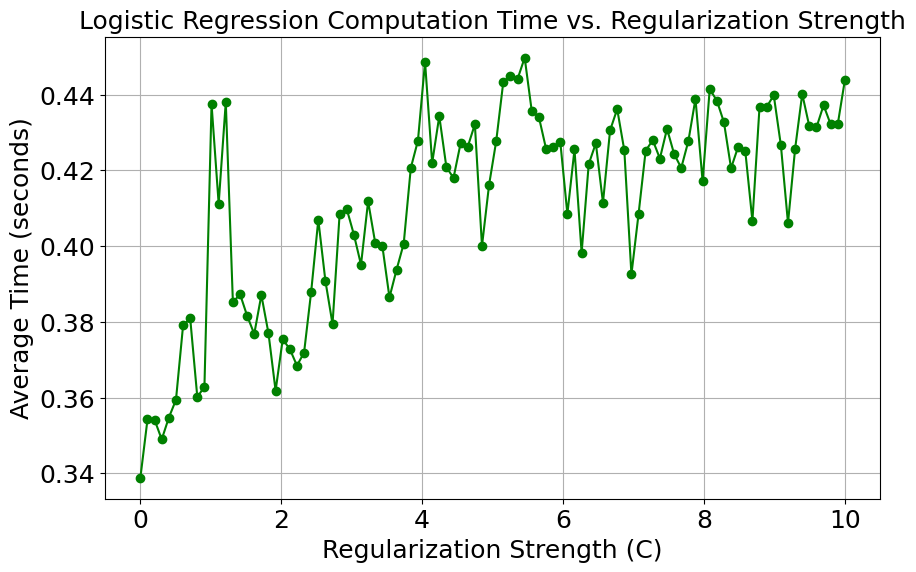

Best Regularization Strength (C): 7.8790000000000004


In [ ]:
from sklearn.linear_model import LogisticRegression

#Initialize the Logistic Regression model
logistic_regression = LogisticRegression(random_state=random_seed, max_iter=1000)

# Define the range of regularization strengths to test
C_range = np.linspace(0.001, 10, 100)


mean_scores_lr = []
std_scores_lr = []
mean_times_lr = []
std_times_lr = []

#Loop through each regularization strength
for C in C_range:
    logistic_regression.set_params(C=C)
    
    #Measure time for cross-validation
    start_time = time.time()
    for _ in range(1,101):
        scores = cross_val_score(logistic_regression, X, y, cv=10, scoring='accuracy', n_jobs=-1)
    elapsed_time = time.time() - start_time
    
    # tore results
    mean_scores_lr.append(scores.mean())
    std_scores_lr.append(scores.std()/np.sqrt(10))
    mean_times_lr.append(elapsed_time / 10)  #Average time per fold

#Plot 
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.errorbar(C_range, mean_scores_lr, yerr=std_scores_lr, fmt='-o', capsize=5, color='blue', ecolor='red')
ax1.set_xlabel("Regularization Strength (C)")
ax1.set_ylabel("Classification Accuracy")
ax1.set_title("Logistic Regression Classification Accuracy vs. Regularization Strength")
ax1.grid(True)

fig, ax2 = plt.subplots(figsize=(10, 6))
ax2.plot(C_range, mean_times_lr, '-o', color='green')
ax2.set_xlabel("Regularization Strength (C)")
ax2.set_ylabel("Average Time (seconds)")
ax2.set_title("Logistic Regression Computation Time vs. Regularization Strength")
ax2.grid(True)

plt.show()

best_C = C_range[np.argmax(mean_scores_lr)]
print(f"Best Regularization Strength (C): {best_C}")


# XGBoost

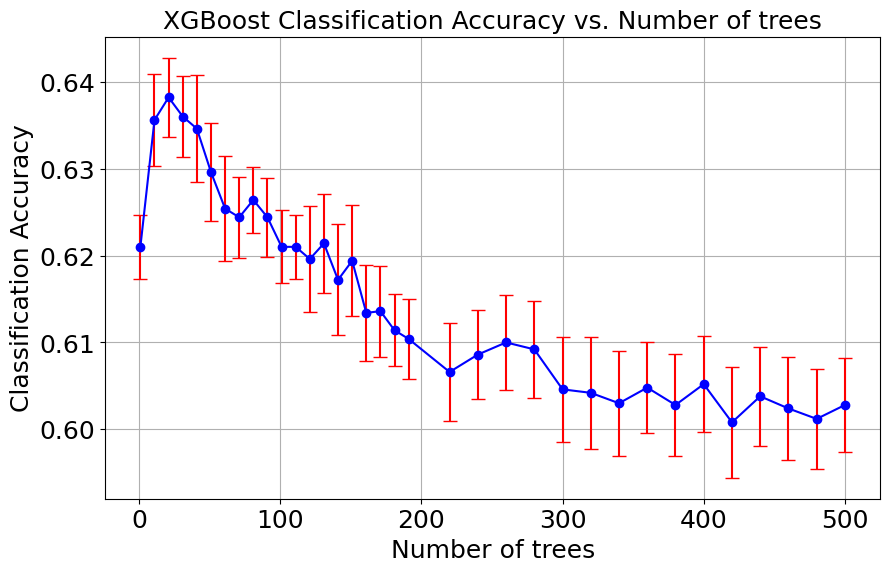

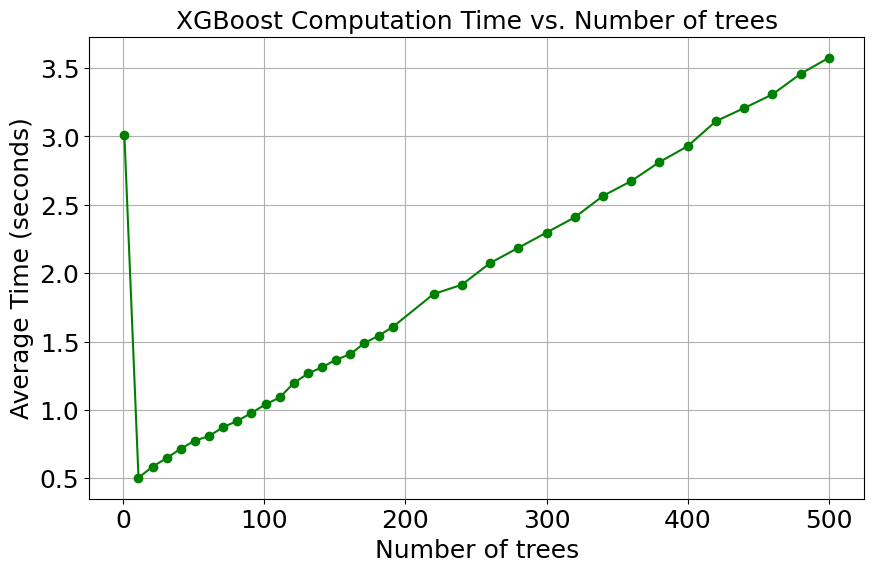

Best number of trees having depth 4: 21


In [ ]:
from xgboost import XGBClassifier

#Initialize the XGBoost Classifier
xgb = XGBClassifier( use_label_encoder=False, eval_metric='logloss', max_depth = 4)

#Define the range of maximum depths to test
max_depth_range = range(1, 51)

#Initialize lists to store results
mean_scores_xgb = []
std_scores_xgb = []
mean_times_xgb = []
std_times_xgb = []

#Define the range of the number of trees to test
n_estimators_range =  list(range(1, 201, 10)) + list(range(220, 501, 20))

#Loop through each maximum depth
for n_estimators in n_estimators_range:
    xgb.set_params(n_estimators=n_estimators)
    
    #Measure time for cross-validation
    start_time = time.time()
    for _ in range(1,101):
        scores = cross_val_score(xgb, X, y, cv=10, scoring='accuracy', n_jobs=-1)
    elapsed_time = time.time() - start_time
    
    #Store results
    mean_scores_xgb.append(scores.mean())
    std_scores_xgb.append(scores.std() / np.sqrt(10))
    mean_times_xgb.append(elapsed_time / 10)  # Average time per fold

#Plot
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.errorbar(n_estimators_range, mean_scores_xgb, yerr=std_scores_xgb, fmt='-o', capsize=5, color='blue', ecolor='red')
ax1.set_xlabel("Number of trees")
ax1.set_ylabel("Classification Accuracy")
ax1.set_title("XGBoost Classification Accuracy vs. Number of trees")
ax1.grid(True)

fig, ax2 = plt.subplots(figsize=(10, 6))
ax2.plot(n_estimators_range, mean_times_xgb, '-o', color='green')
ax2.set_xlabel("Number of trees")
ax2.set_ylabel("Average Time (seconds)")
ax2.set_title("XGBoost Computation Time vs. Number of trees")
ax2.grid(True)

plt.show()

best_n_estimator_xgb = n_estimators_range[np.argmax(mean_scores_xgb)]
print(f"Best number of trees having depth 4: {best_n_estimator_xgb}")


In [ ]:
#Define the optimal parameters for each model
optimal_parameters = {
    "Random Forest": {"Parameter": "n_estimators", "Value": best_n_estimators},
    "Decision Tree": {"Parameter": "max_depth", "Value": best_max_depth},
    "KNN": {"Parameter": "n_neighbors", "Value": best_n_neighbors},
    "SVC": {"Parameter": "kernel", "Value": best_kernel},
    "Logistic Regression": {"Parameter": "C", "Value": best_C},
    "XGBoost": {"Parameter": "n_estimators", "Value": best_n_estimator_xgb},
}

#Convert to DataFrame for easier manipulation
optimal_params_df = pd.DataFrame.from_dict(optimal_parameters, orient="index")

#LaTeX table
latex_table = optimal_params_df.to_latex(
    header=["Optimal Parameter", "Value"],
    index=True,
    index_names=["Model"],
    caption="Optimal Parameters for Each Model",
    label="tab:optimal_parameters"
)

print(latex_table)

\begin{table}
\caption{Optimal Parameters for Each Model}
\label{tab:optimal_parameters}
\begin{tabular}{lll}
\toprule
 & Optimal Parameter & Value \\
\midrule
Random Forest & n_estimators & 31 \\
Decision Tree & max_depth & 4 \\
KNN & n_neighbors & 8 \\
SVC & kernel & poly \\
Logistic Regression & C & 7.879000 \\
XGBoost & n_estimators & 11 \\
\bottomrule
\end{tabular}
\end{table}



In [ ]:
#Define the cost matrix
cost_matrix = {
    'TP': 0,  #True Positive cost
    'FP': 10,  #False Positive cost
    'TN': 0,  #True Negative cost
    'FN': 50   #False Negative cost
}

In [ ]:
#Convert the cost matrix to a DataFrame for easier manipulation
cost_matrix_df = pd.DataFrame.from_dict(cost_matrix, orient="index", columns=["Cost"])

#Generate LaTeX table
latex_table = cost_matrix_df.to_latex(
    header=["Cost"],
    index=True,
    index_names=["Metric"],
    caption="Cost Matrix for Classification",
    label="tab:cost_matrix"
)

print(latex_table)

\begin{table}
\caption{Cost Matrix for Classification}
\label{tab:cost_matrix}
\begin{tabular}{lr}
\toprule
 & Cost \\
\midrule
TP & 0 \\
FP & 10 \\
TN & 0 \\
FN & 50 \\
\bottomrule
\end{tabular}
\end{table}



In [ ]:
#Define the models
models = [
    RandomForestClassifier(random_state=random_seed, max_depth=best_max_depth, n_estimators=best_n_estimators),
    DecisionTreeClassifier(random_state=random_seed, max_depth=best_max_depth),
    KNeighborsClassifier(n_neighbors= best_n_neighbors),
    GaussianNB(),
    SVC(kernel=best_kernel, random_state=random_seed, probability=True),  # Enable probability for SVC
    LogisticRegression(random_state=random_seed, C=best_C, max_iter=1000),
    XGBClassifier(use_label_encoder=False, eval_metric='logloss', max_depth=best_max_depth, n_estimators=best_n_estimator_xgb, random_state = random_seed)
]
model_names = ["Random Forest", "Decision Tree", "KNN", "Naive Bayes", "SVC", "Log Reg", "XGB"]

#Fit each model
for model in models:
    model.fit(X_train, y_train)


c:\Users\magic\OneDrive\Desktop\Programas\Python_programs\myenv\Lib\site-packages\xgboost\training.py:183: UserWarning: [04:06:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Random Forest:
  Total Cost: 13840
  AUC: 0.6667
Decision Tree:
  Total Cost: 14700
  AUC: 0.6291
KNN:
  Total Cost: 16100
  AUC: 0.5984
Naive Bayes:
  Total Cost: 16810
  AUC: 0.6644
SVC:
  Total Cost: 14980
  AUC: 0.6581
Log Reg:
  Total Cost: 14170
  AUC: 0.6766
XGB:
  Total Cost: 13530
  AUC: 0.6661


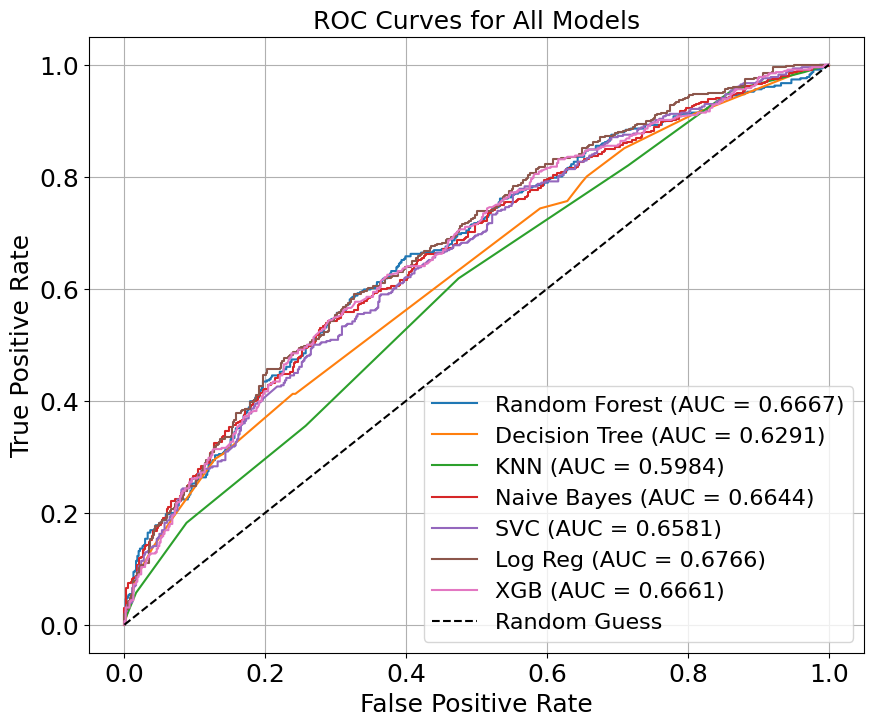

In [ ]:

# Plot all ROC curves on the same plot
plt.figure(figsize=(10, 8))

for model, name in zip(models, model_names):
    #Predictions and probabilities
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)
    
    #Confusion matrix and cost
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    total_cost = (tp * cost_matrix['TP'] +
                  fp * cost_matrix['FP'] +
                  tn * cost_matrix['TN'] +
                  fn * cost_matrix['FN'])
    
    #ROC and AUC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    
    #Print results
    print(f"{name}:")
    print(f"  Total Cost: {total_cost}")
    print(f"  AUC: {auc:.4f}")
    
    #Plot ROC curve
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

#Add random guess line
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend(loc="lower right")
plt.grid()
plt.show()

NOTE: Here I used StratifiedKFold and cross_val_score, I am well aware of that. I just learned about the existance of this other function and It seems to be a more "equilibrated" version of the k-fold cross_val_score. Either way, It should not change too much the results. For more information on StratifiedKFold, please click this [link](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html)

In [ ]:
from sklearn.model_selection import StratifiedKFold
mean_accuracies = []
std_accuracies = []
mean_aucs = []
std_aucs = []
mean_costs = []
std_costs = []

#Perform 10-fold cross-validation for each model
for model, name in zip(models, model_names):
    #Perform cross-validation
    scores = cross_val_score(model, X, y, cv=10, scoring='accuracy', n_jobs=-1)
    mean_accuracies.append(scores.mean())
    std_accuracies.append(scores.std()/np.sqrt(10))
    
    #Perform cross-validation for AUC
    auc_scores = cross_val_score(model, X, y, cv=10, scoring='roc_auc', n_jobs=-1)
    mean_aucs.append(auc_scores.mean())
    std_aucs.append(auc_scores.std()/np.sqrt(10))
    
    #Calculate total cost for each fold
    costs = []
    for train_idx, test_idx in StratifiedKFold(n_splits=10, shuffle=True, random_state=random_seed).split(X, y):
        X_train_cv, X_test_cv = X.iloc[train_idx], X.iloc[test_idx]
        y_train_cv, y_test_cv = y.iloc[train_idx], y.iloc[test_idx]
        
        model.fit(X_train_cv, y_train_cv)
        y_pred_cv = model.predict(X_test_cv)
        tn, fp, fn, tp = confusion_matrix(y_test_cv, y_pred_cv).ravel()
        total_cost = (tp * cost_matrix['TP'] +
                      fp * cost_matrix['FP'] +
                      tn * cost_matrix['TN'] +
                      fn * cost_matrix['FN'])
        costs.append(total_cost)
    
    mean_costs.append(np.mean(costs))
    std_costs.append(np.std(costs)/np.sqrt(10))

#Present the results
results = pd.DataFrame({
    "Model": model_names,
    "Mean Accuracy": mean_accuracies,
    "Accuracy Std": std_accuracies,
    "Mean AUC": mean_aucs,
    "AUC Std": std_aucs,
    "Mean Cost": mean_costs,
    "Cost Std": std_costs
})

print(results)


c:\Users\magic\OneDrive\Desktop\Programas\Python_programs\myenv\Lib\site-packages\xgboost\training.py:183: UserWarning: [04:07:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\magic\OneDrive\Desktop\Programas\Python_programs\myenv\Lib\site-packages\xgboost\training.py:183: UserWarning: [04:07:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\magic\OneDrive\Desktop\Programas\Python_programs\myenv\Lib\site-packages\xgboost\training.py:183: UserWarning: [04:07:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\magic\OneDrive\Desktop\Programas\Python_programs\myenv\Lib\site-packages\xgboost\training.py:183: UserW

           Model  Mean Accuracy  Accuracy Std  Mean AUC   AUC Std  Mean Cost  \
0  Random Forest         0.6328      0.005580  0.680719  0.005580     7109.0   
1  Decision Tree         0.6262      0.003954  0.660992  0.004476     6939.0   
2            KNN         0.5792      0.007591  0.592094  0.011084     7979.0   
3    Naive Bayes         0.6080      0.004724  0.645726  0.009865     8637.0   
4            SVC         0.6288      0.007300  0.670595  0.009407     7304.0   
5        Log Reg         0.6294      0.005099  0.676443  0.006312     7037.0   
6            XGB         0.6386      0.005615  0.687176  0.004888     6593.0   

     Cost Std  
0  109.027061  
1  149.160652  
2  134.152525  
3   62.514798  
4   93.157930  
5  112.872051  
6  125.849513  


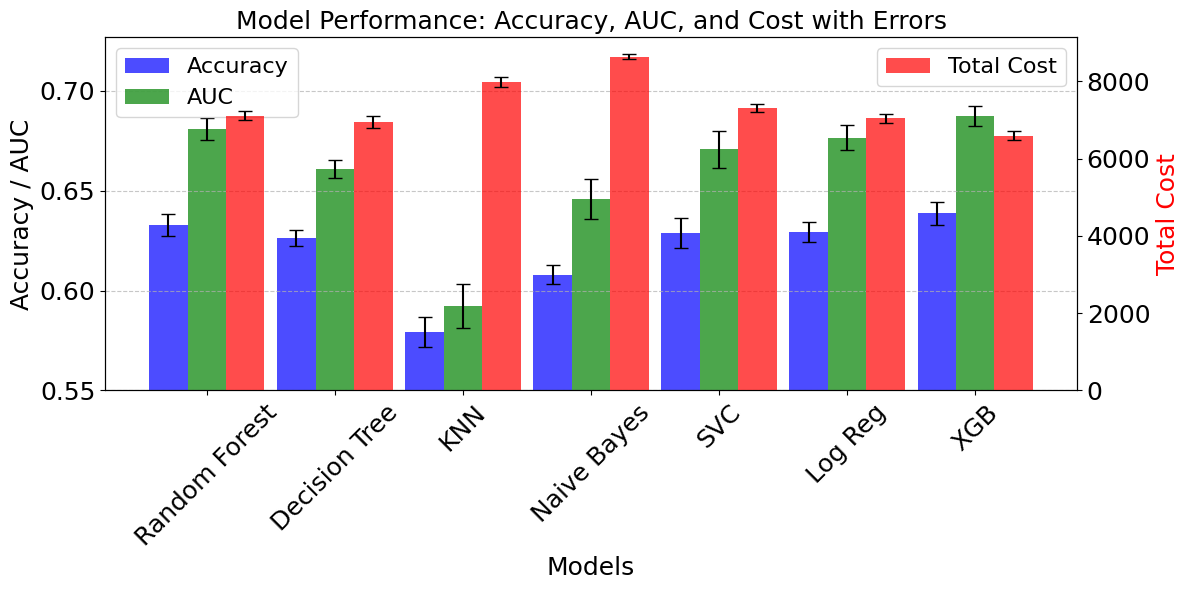

In [ ]:

x = np.arange(len(model_names))  
width = 0.3 

fig, ax1 = plt.subplots(figsize=(12, 6))


bars1 = ax1.bar(x - width, mean_accuracies, width, yerr=std_accuracies, label='Accuracy', color='blue', alpha=0.7, capsize=5)


bars2 = ax1.bar(x, mean_aucs, width, yerr=std_aucs, label='AUC', color='green', alpha=0.7, capsize=5)


ax1.set_xlabel("Models")
ax1.set_ylabel("Accuracy / AUC", color='black')
ax1.set_xticks(x)
ax1.set_xticklabels(model_names, rotation=45)
ax1.legend(loc='upper left')
ax1.set_ylim(bottom=0.55)  
ax1.tick_params(axis='y', labelcolor='black')


ax2 = ax1.twinx()
bars3 = ax2.bar(x + width, mean_costs, width, yerr=std_costs, label='Total Cost', color='red', alpha=0.7, capsize=5)


ax2.set_ylabel("Total Cost", color='red')
ax2.tick_params(axis='y')  


plt.title("Model Performance: Accuracy, AUC, and Cost with Errors")
ax1.grid(axis='y', linestyle='--', alpha=0.7)


ax1.legend(loc='upper left')
ax2.legend(["Total Cost"], loc='upper right')

plt.tight_layout()
plt.show()


----